In [796]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf

In [797]:
years = 3
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365 * years)
startDate

datetime.datetime(2022, 5, 22, 22, 31, 1, 587531)

In [798]:
#all stocks growth 100 risk = 4
allStocksTickers = ['VTI', 'VTV', 'VOE', 'VEA', 'IEFA']
allStocksTickersWeight = [0.2, 0.2, 0.2, 0.2, 0.2]

#all bonds fixed income 100 risk = 1
allbondstickers = ['EMB', 'VWOB', 'BNDX', 'AGG', 'TFI']
allbondsTickersWeight = [0.2, 0.2, 0.2, 0.2, 0.2]

#Balanced 50 50 risk = 2 or 3
tickersBalanced = ['EMB', 'VWOB', 'BNDX', 'VEA', 'IEFA']
tickersBalancedWeight = [0.166, 0.166, 0.166, 0.25, 0.25]

#Income  risk = 2
Incometickers = ['EMB', 'VWOB', 'BNDX', 'VEA', 'IEFA']
WeightIncometickers = [0.3, 0.3, 0.3, 0.05, 0.05]

In [799]:
adjustedClose = pd.DataFrame()

FullName  = []

for ticker in allStocksTickers:
    print(ticker)
    data = yf.download(ticker, start=startDate, end=endDate)
    adjustedClose[ticker] = data['Close']
    
    # Get ETF data
    etf = yf.Ticker(ticker)
    
    # Get the full name of the ETF
    FullName.append(etf.info['shortName'])
    
    # Get expense ratio and other info
    info = etf.info
    
    
print(adjustedClose)
print(FullName)

VTI


[*********************100%***********************]  1 of 1 completed


VTV


[*********************100%***********************]  1 of 1 completed


VOE


...

VEA


[*********************100%***********************]  1 of 1 completed


IEFA


[*********************100%***********************]  1 of 1 completed


                   VTI         VTV         VOE        VEA       IEFA
Date                                                                
2022-05-23  189.794830  129.328156  130.267441  40.668919  59.221073
2022-05-24  187.893600  129.865707  129.810806  40.523838  59.075138
2022-05-25  189.985916  130.764725  131.469650  40.505699  59.075138
2022-05-26  193.874268  132.507141  133.985931  40.950027  59.768322
2022-05-27  198.784912  134.620285  136.679260  41.457817  60.452374
...                ...         ...         ...        ...        ...
2025-05-15  290.589996  171.440002  162.559998  54.380001  80.900002
2025-05-16  292.579987  173.100006  164.149994  54.500000  81.080002
2025-05-19  292.809998  173.320007  164.050003  54.939999  81.820000
2025-05-20  291.850006  172.979996  163.759995  55.200001  82.230003
2025-05-21  286.769989  169.880005  160.399994  54.900002  81.750000

[752 rows x 5 columns]
['Vanguard Total Stock Market ETF', 'Vanguard Value ETF', 'Vanguard Mid-Cap Val

Daily log returns

In [800]:
logReturns = np.log(adjustedClose / adjustedClose.shift(1))
logReturns = logReturns.dropna()
print(logReturns)

                 VTI       VTV       VOE       VEA      IEFA
Date                                                        
2022-05-24 -0.010068  0.004148 -0.003512 -0.003574 -0.002467
2022-05-25  0.011074  0.006899  0.012698 -0.000448  0.000000
2022-05-26  0.020260  0.013237  0.018959  0.010910  0.011666
2022-05-27  0.025014  0.015822  0.019902  0.012324  0.011380
2022-05-31 -0.008252 -0.008018 -0.008491 -0.004604 -0.005750
...              ...       ...       ...       ...       ...
2025-05-15  0.004069  0.011616  0.013189  0.010537  0.010812
2025-05-16  0.006825  0.009636  0.009733  0.002204  0.002223
2025-05-19  0.000786  0.001270 -0.000609  0.008041  0.009085
2025-05-20 -0.003284 -0.001964 -0.001769  0.004721  0.004999
2025-05-21 -0.017560 -0.018084 -0.020731 -0.005450 -0.005854

[751 rows x 5 columns]


create an weight portfolio

In [801]:
portfolioValue = 1000

#all stocks growth 100 risk = 4
allStocksTickers = ['VTI', 'VTV', 'VOE', 'VEA', 'IEFA']
allStocksTickersWeight = [0.2, 0.2, 0.2, 0.2, 0.2]

#all bonds fixed income 100 risk = 1
allbondstickers = ['EMB', 'VWOB', 'BNDX', 'AGG', 'TFI']
allbondsTickersWeight = [0.2, 0.2, 0.2, 0.2, 0.2]

#Balanced 50 50 risk = 2 or 3
tickersBalanced = ['EMB', 'VWOB', 'BNDX', 'VEA', 'IEFA']
tickersBalancedWeight = [0.166, 0.166, 0.166, 0.25, 0.25]

#Income  risk = 2
Incometickers = ['EMB', 'VWOB', 'BNDX', 'VEA', 'IEFA']
WeightIncometickers = [0.3, 0.3, 0.3, 0.05, 0.05]

weights = np.array(allStocksTickersWeight)
weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [802]:
df2 = pd.DataFrame({
    'Ticker': tickers,
    'FullName': FullName,
    'Weight': weights,
    
})
print(df2)

  Ticker                         FullName  Weight
0    VTI  Vanguard Total Stock Market ETF     0.2
1    VTV               Vanguard Value ETF     0.2
2    VOE       Vanguard Mid-Cap Value ETF     0.2
3    VEA  Vanguard FTSE Developed Markets     0.2
4   IEFA       iShares Core MSCI EAFE ETF     0.2


In [803]:
# Create labels with ticker and full name
labels = [f"{ticker}\n({name})" for ticker, name in zip(df2['Ticker'], df2['FullName'])]

# Create pie chart
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    df2['WeightWeight'],
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'],
    textprops={'fontsize': 10}
)

# Style the percentages
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)

# Add title
plt.title('Portfolio Asset Allocation', fontsize=16, pad=20)

# Equal aspect ratio ensures pie is drawn as circle
plt.axis('equal')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

KeyError: 'WeightWeight'

<Figure size 1000x800 with 0 Axes>

Calc historical returns

In [ ]:
historicalReturns = (logReturns * weights).sum(axis=1)
print(historicalReturns)

Date
2022-05-24   -0.003094
2022-05-25    0.006045
2022-05-26    0.015006
2022-05-27    0.016888
2022-05-31   -0.007023
                ...   
2025-05-15    0.010045
2025-05-16    0.006124
2025-05-19    0.003715
2025-05-20    0.000541
2025-05-21   -0.013561
Length: 751, dtype: float64


In [ ]:
type(historicalReturns)


pandas.core.series.Series

In [ ]:
average_return = historicalReturns.mean()
print("Average Daily Return:", average_return)

Average Daily Return: 0.0004036932857785811


In [ ]:
annualized_return = (1 + average_return) ** 252 - 1
print("Annualized Return:", annualized_return)
returns_percent = (annualized_return * 100).round(2).astype(str) + '%'
print(returns_percent)

Annualized Return: 0.10706257584289514
10.71%


In [ ]:
df = pd.DataFrame({
    'Dividend Yield': [returns_percent],
    'Dividend Amount': [annualized_return * portfolioValue]
})
print(df)

  Dividend Yield  Dividend Amount
0         10.71%       107.062576


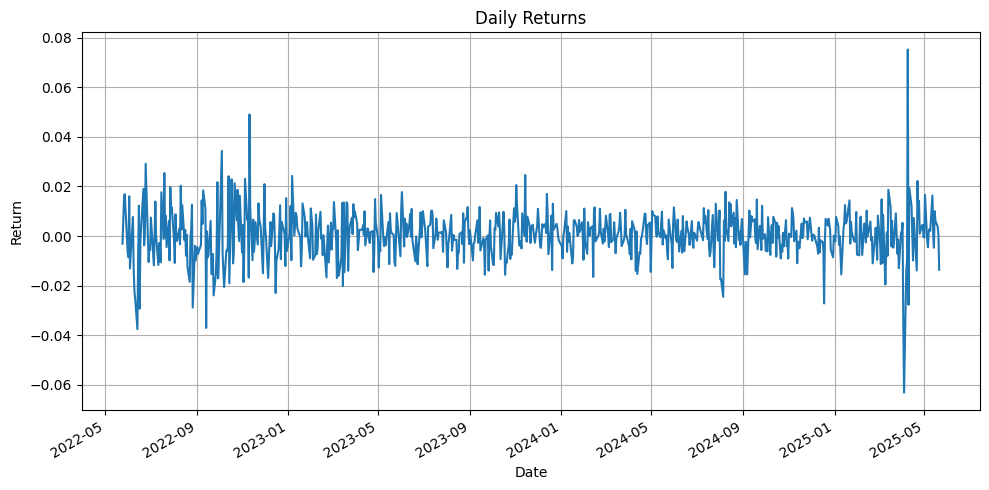

In [ ]:
# Assuming your Series is called `returns_series`
historicalReturns.plot(figsize=(10, 5), title="Daily Returns", legend=False)
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
historicalVariance = historicalReturns.var()
print("Historical Variance of the Portfolio:", historicalVariance)

annualizedVariance = historicalReturns.var() * 252
print("Annualized Variance of the Portfolio:", annualizedVariance)


Historical Variance of the Portfolio: 9.838247976254696e-05
Annualized Variance of the Portfolio: 0.024792384900161835


In [ ]:
df3 = pd.DataFrame({
    '3-year Variance': [historicalVariance],
    'Annualized Variance': [annualizedVariance]
})
print(df3)

   3-year Variance  Annualized Variance
0         0.000098             0.024792


In [ ]:
day = 5
rangeReturns = historicalReturns.rolling(window=day).sum()
rangeReturns = historicalReturns.dropna()
print(rangeReturns)


Date
2022-05-24   -0.003094
2022-05-25    0.006045
2022-05-26    0.015006
2022-05-27    0.016888
2022-05-31   -0.007023
                ...   
2025-05-15    0.010045
2025-05-16    0.006124
2025-05-19    0.003715
2025-05-20    0.000541
2025-05-21   -0.013561
Length: 751, dtype: float64


In [ ]:
confidenceLevel = 0.95

VaR = -np.percentile(rangeReturns, 100 - (confidenceLevel * 100)) * portfolioValue
print(f"VaR at {confidenceLevel * 100}% confidence level: ${VaR:.2f}")

VaR at 95.0% confidence level: $15.02


plot

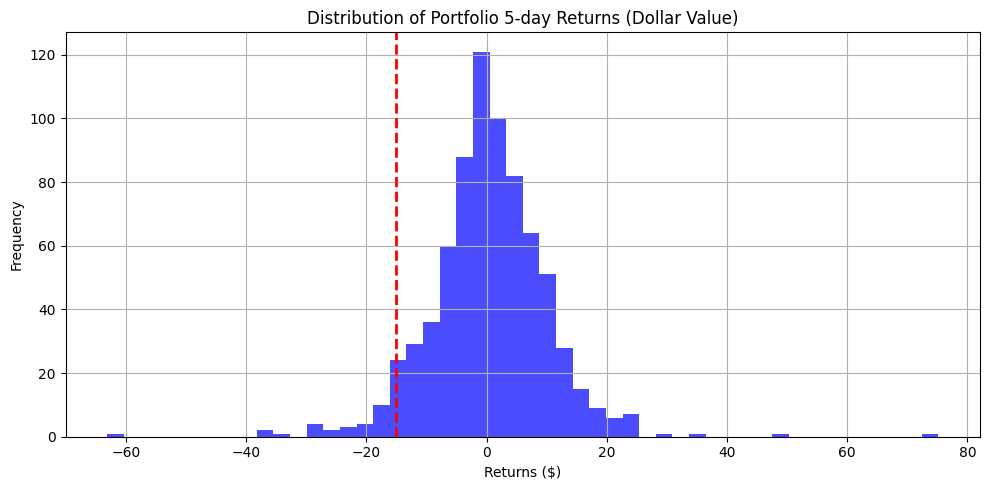

In [ ]:
returnWindow = day
rangeReturns = historicalReturns.rolling(window=day).sum()
rangeReturns = historicalReturns.dropna()

rangeReturnsDollar = rangeReturns * portfolioValue

plt.figure(figsize=(10, 5))
plt.hist(rangeReturnsDollar.dropna(), bins=50, alpha=0.7, color='blue')
plt.axvline(-VaR, color='red', linestyle='dashed', linewidth=2)    
plt.title(f"Distribution of Portfolio {returnWindow}-day Returns (Dollar Value)")
plt.xlabel("Returns ($)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

